In [ ]:
# Cell 0: Install libraries + Load dataset
# using 5 images for Check-in 3, will expand to 50 for final submission

!pip install opencv-python matplotlib scikit-image datasets

from datasets import load_dataset
dataset = load_dataset("yangtao9009/Flickr2K", split="train[:5]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

Flickr2K.zip:   0%|          | 0.00/11.6G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
# Cell 1: Clone Toey's DnCNN branch
# contains: src/download_data.py, src/degrade_images.py,
#           src/dncnn_pytorch.py, src/dncnn_weights.py
#           requirements.txt

!git clone -b DnCNN https://github.com/toeyldev/cmpe189-ai-photo-enhancement.git
%cd cmpe189-ai-photo-enhancement
!pip install -r requirements.txt

Cloning into 'cmpe189-ai-photo-enhancement'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 89 (delta 30), reused 60 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 5.58 MiB | 11.36 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/cmpe189-ai-photo-enhancement
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.5 MB/s eta 0:00:00


In [ ]:
# Cell 2: Run Toey's pipeline scripts
# download_data.py  → downloads clean images from Flickr2K
# degrade_images.py → generates degraded versions

!python src/download_data.py
!python src/degrade_images.py

Dataset({
    features: ['image'],
    num_rows: 50
})
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2040x1356 at 0x787D5BD24C20>}
Done saving clean images.
Done creating degraded images.


In [ ]:
# Cell 3: Save clean images to data/clean/

import os

os.makedirs("data/clean", exist_ok=True) #exist_ok=True = avoid errors if folder exists

for i, item in enumerate(dataset):
  img = item["image"] #key -> image as value on dict

  #save image into the folder
  img.save(f"data/clean/image_{i}.png")

**cv2: OpenCV (Open Source Computer Vision Library) in Python**

It's a library used for:
* image processing
* computer vision
* video processing

1. Read an image

img = cv2.imread("image.png")
img is a 3D numpy Array of numbers

- Loads image into a NumPy array
- img.shape → (height, width, channels)

2. Save an image

cv2.imwrite("output.png", img)

- Writes image to disk

3. Resize image

resized = cv2.resize(img, (256, 256))

or scale:

small = cv2.resize(img, None, fx=0.5, fy=0.5)

- Used to simulate low resolution

4. Convert color (VERY IMPORTANT)

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

- OpenCV uses BGR, but matplotlib uses RGB

BGR = [Blue, Green, Red]

RGB = [Red, Green, Blue]

In [ ]:
# Cell 5: Generate degraded images
# Pipeline: clean → downsample → upsample → add noise → degraded

"""
clean image
   ↓
downsample → lose detail
   ↓
upsample → blur
   ↓
add noise → realistic degradation
   ↓
save → degraded image
"""

import cv2
import numpy as np
import os

os.makedirs("data/degraded", exist_ok=True)

#return: ["image_0.png", "image_1.png", ...]
#getFilename (Ex:image_0.png)
for fileName in os.listdir("data/clean"):

  #"data/clean" + "image_0.png"
  #builds: data/clean/image_0.png
  path = os.path.join("data/clean", fileName)

  # 1. clean image
  img = cv2.imread(path)
  #cv2.imread() takes a file path string and reads the image from disk into a NumPy array

  #if cv2.imread() fails: return None object
  if img is None:
        print(f"Could not read {path}")
        continue

  # 2. downsized image
  #We want: same size image, but lower quality
  #dsize (Width, Height) = None -> No hardcoded
  #fx=0.2 → new width = original width × 0.2 (20%)
  #fy=0.2 → new height = original height × 0.2 (20%)
  downSized = cv2.resize(img, None, fx=0.2, fy=0.2, interpolation=cv2.INTER_AREA)

  # 3. upsized image
  #Resize back to the original width and height
  #img.shape → (height, width, channels)
  # NumPy order: cv2.resize() → (width, height) # OpenCV order
  upSized = cv2.resize(downSized, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_CUBIC)

  # 4. noisy image
  #noise = the disturbance
  #generate noise: mean = 0, std = 50 (controls noise strength), same shape as image
  #~68% of values → between -50 and +50
  noise = np.random.normal(0, 50, img.shape)

  """
  Original pixel: [100, 150, 200]
  Noise:          [+10,  -20,  +5]
  --------------------------------
  Result:         [110, 130, 205]
  """

  #noisy = the degraded image or noisy = upSizeImg + noise
  #0-255 = value of each pixel
  # astype(np.uint8): 123.7 → 123
  noisyImage = np.clip(upSized + noise, 0, 255).astype(np.uint8)

  savePath = os.path.join("data/degraded", fileName)
  cv2.imwrite(savePath, noisyImage)

print("Done creating degraded images.")
!ls data/degraded | head

Done creating degraded images.
image_0.png
image_10.png
image_11.png
image_12.png
image_13.png
image_14.png
image_15.png
image_16.png
image_17.png
image_18.png


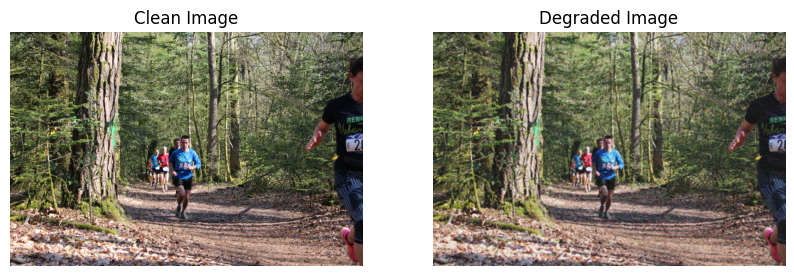

In [ ]:
# Cell 6: Visualize Clean vs Degraded

"""
Visualization Cell: Compare Clean vs Degraded Image

1. Load both clean and degraded images from disk using cv2.imread() (returns NumPy array in BGR order)
2. Convert BGR → RGB using cv2.cvtColor() so matplotlib displays colors correctly
3. Create a shared figure (10x4 inches) with plt.figure()
4. Split figure into 2 side-by-side subplots using plt.subplot(1, 2, position)
   - position 1 (left)  → clean image
   - position 2 (right) → degraded image
5. Display the full figure with plt.show()

Key notes:
- OpenCV uses BGR order, matplotlib expects RGB → conversion needed
- plt.figure() is the shared canvas for both subplots
- plt.axis("off") hides axis ticks for cleaner image display
- subplot positions are 1-based (not 0-based like arrays)
"""

import cv2
import matplotlib.pyplot as plt

clean_path = cv2.imread("data/clean/image_0.png")
degraded_path = cv2.imread("data/degraded/image_0.png")

#OpenCV reads:      [B, G, R]  per pixel
#matplotlib wants:  [R, G, B]  per pixel
clean_rgb = cv2.cvtColor(clean_path, cv2.COLOR_BGR2RGB)
degraded_rgb = cv2.cvtColor(degraded_path, cv2.COLOR_BGR2RGB)

#plt.figure(): creates a new blank figure
# figsize=(10, 4):  width-height (in inches)
plt.figure(figsize=(10, 4)) # <- creates ONE shared figure

plt.subplot(1, 2, 1)       # <- draws inside that figure, position 1
plt.imshow(clean_rgb)
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1, 2, 2)      # <- draws inside SAME figure, position 2
plt.imshow(degraded_rgb)
plt.title("Degraded Image")
plt.axis("off")

plt.show()

In [ ]:
#degraded image → DnCNN → denoised image

#Step 1: Install dependencies
!pip install torch torchvision

In [ ]:
# TEMPORARY DEBUG CELL - run this first to inspect weight file
import torch

state_dict = torch.load("dncnn_color_blind.pth", map_location="cpu")

if "params" in state_dict:
    state_dict = state_dict["params"]

# print all layer names and shapes
print("Keys in weight file:")
for k in state_dict.keys():
    print(k, "→", state_dict[k].shape)

Keys in weight file:
model.0.weight → torch.Size([64, 3, 3, 3])
model.0.bias → torch.Size([64])
model.2.weight → torch.Size([64, 64, 3, 3])
model.2.bias → torch.Size([64])
model.4.weight → torch.Size([64, 64, 3, 3])
model.4.bias → torch.Size([64])
model.6.weight → torch.Size([64, 64, 3, 3])
model.6.bias → torch.Size([64])
model.8.weight → torch.Size([64, 64, 3, 3])
model.8.bias → torch.Size([64])
model.10.weight → torch.Size([64, 64, 3, 3])
model.10.bias → torch.Size([64])
model.12.weight → torch.Size([64, 64, 3, 3])
model.12.bias → torch.Size([64])
model.14.weight → torch.Size([64, 64, 3, 3])
model.14.bias → torch.Size([64])
model.16.weight → torch.Size([64, 64, 3, 3])
model.16.bias → torch.Size([64])
model.18.weight → torch.Size([64, 64, 3, 3])
model.18.bias → torch.Size([64])
model.20.weight → torch.Size([64, 64, 3, 3])
model.20.bias → torch.Size([64])
model.22.weight → torch.Size([64, 64, 3, 3])
model.22.bias → torch.Size([64])
model.24.weight → torch.Size([64, 64, 3, 3])
model.24.

In [ ]:
# Cell 8: DnCNN Model Loading
#--- Toey (DnCNN - Priority)
#* Load pretrained DnCNN
#* Run inference on degraded images
#* Save denoised outputs

import torch
import torch.nn as nn

# detect GPU - use it if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1: Download RGB pretrained weights
# dncnn_color_blind.pth = color version of DnCNN (channels=3, trained on RGB images)
# Source: cszn/KAIR official releases
!wget -O dncnn_color_blind.pth https://github.com/cszn/KAIR/releases/download/v1.0/dncnn_color_blind.pth

# Step 2: Define DnCNN model matching exact weight file architecture
# confirmed from weight file inspection:
# - 20 layers total (model.0 to model.38, step 2)
# - no BatchNorm (just Conv2d + ReLU alternating)
# - bias=True on all layers
# - first layer:  [64, 3,  3, 3] → 3 input channels (RGB)
# - middle layers:[64, 64, 3, 3] → 64 channels
# - last layer:   [3,  64, 3, 3] → 3 output channels (RGB)

class DnCNN(nn.Module):
    def __init__(self, channels=3, num_of_layers=20, features=64):
        super(DnCNN, self).__init__()

        layers = []
        # first layer: channels → features
        layers.append(nn.Conv2d(channels, features, 3, padding=1, bias=True))
        layers.append(nn.ReLU(inplace=True))

        # middle layers: features → features (no BatchNorm)
        for _ in range(num_of_layers - 2):
            layers.append(nn.Conv2d(features, features, 3, padding=1, bias=True))
            layers.append(nn.ReLU(inplace=True))

        # last layer: features → channels
        layers.append(nn.Conv2d(features, channels, 3, padding=1, bias=True))

        # name must be "model" to match weight keys: model.0, model.2, etc.
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        noise = self.model(x)
        return x - noise  # residual learning: output = input - predicted noise

# Step 3: Load pretrained weights
state_dict = torch.load("dncnn_color_blind.pth", map_location=device)

if "params" in state_dict:
    state_dict = state_dict["params"]

model = DnCNN(channels=3, num_of_layers=20)  # 20 layers confirmed from weight file
model.load_state_dict(state_dict, strict=True)  # strict=True catches weight mismatches
model = model.to(device)                         # move model to GPU
model.eval()

print("RGB DnCNN model loaded successfully on", device)

Using device: cuda
--2026-04-09 00:50:18--  https://github.com/cszn/KAIR/releases/download/v1.0/dncnn_color_blind.pth
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/228241233/1ae767f9-d5e6-4569-939b-ce71db3cdc1c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-09T01%3A41%3A48Z&rscd=attachment%3B+filename%3Ddncnn_color_blind.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-09T00%3A41%3A00Z&ske=2026-04-09T01%3A41%3A48Z&sks=b&skv=2018-11-09&sig=8I3Bv53t9%2BdG%2FBoLc5xcfmnGy%2B15zO1kHIUF04lCSyg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NTY5NTk3OCwibmJmIjoxNzc1Njk1Njc4LCJwYXRoIjoicmVsZWFzZ

## When do we use Pandas vs PyTorch?

---

### Pandas — Data Manipulation & Analysis
Think of it like **Excel in Python** — used for tables, CSVs, and structured data.
```python
import pandas as pd

df = pd.DataFrame(results)  # create table
df.to_csv("results.csv")    # save to CSV
df.mean()                   # compute averages
df.to_string()              # display table
```

**Use Pandas when you need to:**
- Store and display structured data (tables, spreadsheets)
- Compute statistics (mean, max, min)
- Read/write CSV files
- Organize and present results

---

### PyTorch — Deep Learning & Neural Networks
Think of it like the **engine that runs the AI model** — used for tensors, neural networks, and GPU computation.
```python
import torch

img_tensor = torch.from_numpy(img)  # convert image to tensor
model = DnCNN()                      # define neural network
output = model(img_tensor)           # run inference
torch.load("weights.pth")           # load pretrained weights
```

**Use PyTorch when you need to:**
- Define neural network architectures
- Run model inference
- Train models
- Work with tensors (multi-dimensional arrays optimized for math/GPU)

## Key Concepts from Task 3: Results Table Cell

---

### 1. PyTorch Tensor
Like a NumPy array but optimized for neural networks:
```
NumPy array    → general math/computation, CPU only
PyTorch tensor → same idea, but can run on GPU and tracks gradients for training
```

### 2. Why convert (H, W, C) → (C, H, W)?
```
NumPy   → (H, W, C)  channels LAST    → img[y][x][channel]
PyTorch → (C, H, W)  channels FIRST   → tensor[channel][y][x]
```

### 3. Why does unsqueeze(0) add a 1? (Batch Dimension)
```
(C, H, W)    → single image       ← model rejects this
(1, C, H, W) → batch of 1 image   ← model accepts this
(8, C, H, W) → batch of 8 images  ← also valid
```

### 4. Forward vs Backward Tensor Conversion
```
Forward (NumPy → Tensor):          Backward (Tensor → NumPy):
(H, W, C)                          (1, C, H, W)
  ↓ permute(2, 0, 1)                 ↓ squeeze()
(C, H, W)                          (C, H, W)
  ↓ unsqueeze(0)                     ↓ permute(1, 2, 0)
(1, C, H, W)                       (H, W, C)
  ↓ float()                          ↓ numpy()
tensor float32                     NumPy array float32
```

### 5. torch.no_grad()
```
without no_grad → tracks every operation (slow, uses extra memory)
with no_grad    → just computes the output  (fast, memory efficient)
```

### 6. PSNR vs SSIM
```
PSNR  → pixel-level accuracy  → higher is better (measured in dB)
SSIM  → structural similarity → higher is better (range 0.0 to 1.0)
```

In [ ]:
# Cell 11: Task 2 - PSNR/SSIM single image test
# quick test on ONE image to verify everything works before running the full loop

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import cv2
import torch
import numpy as np

# use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#compare_img: can be degraded image or denoised image
def compute_metrics(clean_img, compare_img):
    """
    Compute PSNR and SSIM between two images.
    Both images must be RGB uint8 NumPy arrays of the same shape.

    PSNR: higher is better (measures pixel-level accuracy)
    SSIM: higher is better, range 0-1 (measures structural similarity)
    """
    psnr_val = psnr(clean_img, compare_img)
    ssim_val = ssim(clean_img, compare_img, channel_axis=2)
    #channel_axis=2: tell SSIM which axis of NumPy contains the color channels
    #img.shape returns (height, width, channels)
    return psnr_val, ssim_val


# Load clean image (ground truth)
# data/ is inside cmpe189-ai-photo-enhancement/ which is our current working directory
clean = cv2.imread("data/clean/image_0.png")
clean_rgb = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB) #[B, G, R] to [R, G, B]

# Load degraded image (model input / baseline)
degraded = cv2.imread("data/degraded/image_0.png")
degraded_rgb = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)

# Compute baseline metrics (degraded vs clean)
psnr_degraded, ssim_degraded = compute_metrics(clean_rgb, degraded_rgb)

# run inference on image_0 to generate "out"
# make sure it is uint8 RGB at this point
img_norm   = degraded_rgb / 255.0                                               # min-max normalization to [0, 1]
img_tensor = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0).float()  # NumPy (H,W,C) → tensor (1,C,H,W)
img_tensor = img_tensor.to(device)                                              # move tensor to GPU

with torch.no_grad():   # no_grad → fast, memory efficient (no gradient tracking needed at inference)
    output = model(img_tensor)

# convert output tensor back to uint8 NumPy image
# .cpu() moves tensor back from GPU to CPU before converting to NumPy
out = output.squeeze().cpu().permute(1, 2, 0).numpy()  # (1,C,H,W) → (H,W,C)
out = np.clip(out * 255, 0, 255).astype(np.uint8)      # [0,1] → [0,255], float32 → uint8

# Compute model metrics (denoised vs clean)
psnr_denoised, ssim_denoised = compute_metrics(clean_rgb, out)

print(f"PSNR  - Degraded: {psnr_degraded:.2f} dB  |  Denoised: {psnr_denoised:.2f} dB")
print(f"SSIM  - Degraded: {ssim_degraded:.4f}     |  Denoised: {ssim_denoised:.4f}")

Using device: cuda
PSNR  - Degraded: 13.62 dB  |  Denoised: 19.14 dB
SSIM  - Degraded: 0.1465     |  Denoised: 0.4166


In [ ]:
# Cell 12: Task 3 - Generate Results Table

import pandas as pd
import cv2
import os
import numpy as np
import torch

"""
Results Table Cell:
- Loops over all clean/degraded image pairs
- Runs DnCNN inference on each degraded image
- Computes PSNR and SSIM for:
    * degraded vs clean  (baseline)
    * denoised vs clean  (model output)
- Builds a pandas DataFrame and prints the results table
"""

#create a list (of dictionary later)
results = []

clean_dir    = "data/clean"
degraded_dir = "data/degraded"
enhanced_dir = "data/enhanced"
os.makedirs(enhanced_dir, exist_ok=True)

for fileName in sorted(os.listdir(clean_dir)):

    # --- Load images ---
    clean_path    = os.path.join(clean_dir, fileName)
    degraded_path = os.path.join(degraded_dir, fileName)

    clean    = cv2.imread(clean_path)
    degraded = cv2.imread(degraded_path)

    if clean is None or degraded is None:
        print(f"Skipping {fileName} - could not read file")
        continue

    # --- Convert BGR → RGB ---
    #cv2.cvtColor() always returns a 3D NumPy array
    clean_rgb    = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)
    degraded_rgb = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)

    # --- Run DnCNN inference ---
    # normalize → tensor → model → back to uint8 RGB

    """
    min-max formula:  (x - min) / (max - min)
                = (x - 0)   / (255 - 0)
                = x / 255
    Since min is always 0 for images, the formula simplifies to just / 255.0.
    """

    img_norm   = degraded_rgb / 255.0                                               # min-max normalization to [0, 1]
    img_tensor = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0).float()  # NumPy (H,W,C) → tensor (1,C,H,W)
    img_tensor = img_tensor.to(device)                                              # move tensor to GPU

    """
    torch.from_numpy(img_norm)   # NumPy array (H, W, C)  → PyTorch tensor (H, W, C)
    .permute(2, 0, 1)            # (H, W, C)              → (C, H, W)  PyTorch order
    .unsqueeze(0)                # (C, H, W)              → (1, C, H, W) adds batch dimension
    .float()                     # converts to float32 (model expects float, not uint8)
    """

    # with no_grad → PyTorch just computes the output (fast, memory efficient)
    # Gradients are only needed during training to update weights
    with torch.no_grad():
        output = model(img_tensor)  # model is Toey's DnCNN with pretrained weights loaded
                                    # output is a 4D PyTorch tensor containing the denoised image

    # Converting output tensor back to image
    """
    Forward (NumPy → Tensor):          Backward (Tensor → NumPy):
    (H, W, C)                          (1, C, H, W)
      ↓ permute(2, 0, 1)                 ↓ squeeze()
    (C, H, W)                          (C, H, W)
      ↓ unsqueeze(0)                     ↓ permute(1, 2, 0)
    (1, C, H, W)                       (H, W, C)
      ↓ float()                          ↓ numpy()
    tensor float32                     NumPy array float32
    """

    # .cpu() moves tensor back from GPU to CPU before converting to NumPy
    denoised = output.squeeze().cpu().permute(1, 2, 0).numpy()  # (1,C,H,W) → (H,W,C)

    # earlier we did: img_norm = degraded_rgb / 255.0  →  [0, 255] to [0.0, 1.0]
    # now we undo it: denoised * 255                   →  [0.0, 1.0] to [0.0, 255.0]
    denoised = np.clip(denoised * 255, 0, 255).astype(np.uint8)

    # --- Save enhanced image for Ryan ---
    save_path = os.path.join(enhanced_dir, fileName)
    # OpenCV saves images in BGR order, so convert RGB → BGR before saving
    denoised_bgr = cv2.cvtColor(denoised, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, denoised_bgr)

    # --- Compute metrics ---
    # This runs (PSNR & SSIM) on every image to build the full results table
    psnr_degraded, ssim_degraded = compute_metrics(clean_rgb, degraded_rgb)
    psnr_denoised, ssim_denoised = compute_metrics(clean_rgb, denoised)

    #results is a list of dictionaries: each loop iteration appends one dictionary (one row of data)
    #SSIM uses 4 decimal places because it's a small number between 0-1
    results.append({
        "image"         : fileName,
        "PSNR_degraded" : round(psnr_degraded, 2),
        "PSNR_denoised" : round(psnr_denoised, 2),
        "SSIM_degraded" : round(ssim_degraded, 4),
        "SSIM_denoised" : round(ssim_denoised, 4),
    })

# --- Build and display table ---
# Converts the list of dictionaries into a pandas table automatically
# each dictionary becomes one row, each key becomes one column
df = pd.DataFrame(results)

# Add average row at the bottom
# df.mean(numeric_only=True) computes the average of each numeric column
# skipping the "image" column (since you can't average strings)
# avg_row is a pandas Series
avg_row = df.mean(numeric_only=True).round(4)

# restoring the "image" label that df.mean() dropped because it couldn't average strings
avg_row["image"] = "AVERAGE"

"""
avg_row.to_frame()   # converts Series (1D) → DataFrame (2D column)
.T                   # transposes column → row (so it matches table shape)
pd.concat([df, ...]) # appends average row to bottom of table
ignore_index=True    # resets row numbering after concat
"""
df = pd.concat([df, avg_row.to_frame().T], ignore_index=True)

print(df.to_string(index=False))

# save to CSV for report
df.to_csv("results_table.csv", index=False)
print("Saved results to results_table.csv")

       image PSNR_degraded PSNR_denoised SSIM_degraded SSIM_denoised
 image_0.png         13.62         19.14        0.1465        0.4166
 image_1.png         14.03         20.07        0.1224        0.4426
image_10.png         14.21         20.96        0.1178        0.5685
image_11.png         15.37         28.92        0.0517        0.8525
image_12.png          14.6         23.71        0.0897        0.7291
image_13.png         14.66         24.18        0.1086        0.7177
image_14.png         14.56         23.99        0.1038         0.706
image_15.png         14.31         25.21        0.0635        0.7523
image_16.png         14.68         24.46        0.0693        0.6437
image_17.png          14.4         21.15        0.0815        0.4721
image_18.png         15.05          27.2        0.0757        0.7764
image_19.png         15.01         24.22        0.0917        0.7296
 image_2.png         14.09         21.66        0.0887        0.6621
image_20.png         13.81        

In [ ]:
# Cell 13: Zahid Khan - Comparison & Analysis Section
# computes per-image improvement from DnCNN denoising

import pandas as pd

df = pd.read_csv("results_table.csv")

# remove average row for per-image analysis
df_images = df[df["image"] != "AVERAGE"].copy()

# compute improvement per image
# positive gain = model improved the image
# negative gain = model made it worse (should not happen with good weights)
df_images["PSNR_gain"] = df_images["PSNR_denoised"] - df_images["PSNR_degraded"]
df_images["SSIM_gain"] = df_images["SSIM_denoised"] - df_images["SSIM_degraded"]

# print before → after averages
print("Average PSNR:", round(df_images["PSNR_degraded"].mean(), 2), "→", round(df_images["PSNR_denoised"].mean(), 2))
print("Average SSIM:", round(df_images["SSIM_degraded"].mean(), 4), "→", round(df_images["SSIM_denoised"].mean(), 4))

# per-image improvement table
print("\nImprovement check:")
print(df_images[["image", "PSNR_gain", "SSIM_gain"]].to_string(index=False))

Average PSNR: 14.49 → 24.08
Average SSIM: 0.0833 → 0.6499

Improvement check:
       image  PSNR_gain  SSIM_gain
 image_0.png       5.52     0.2701
 image_1.png       6.04     0.3202
image_10.png       6.75     0.4507
image_11.png      13.55     0.8008
image_12.png       9.11     0.6394
image_13.png       9.52     0.6091
image_14.png       9.43     0.6022
image_15.png      10.90     0.6888
image_16.png       9.78     0.5744
image_17.png       6.75     0.3906
image_18.png      12.15     0.7007
image_19.png       9.21     0.6379
 image_2.png       7.57     0.5734
image_20.png       5.69     0.2952
image_21.png       8.06     0.4298
image_22.png      12.86     0.6499
image_23.png       8.25     0.4861
image_24.png      17.45     0.8361
image_25.png       6.84     0.4150
image_26.png       7.19     0.3690
image_27.png      11.59     0.6989
image_28.png      17.44     0.8689
image_29.png      12.11     0.7365
 image_3.png       7.91     0.4886
image_30.png      16.21     0.8046
image_31.png

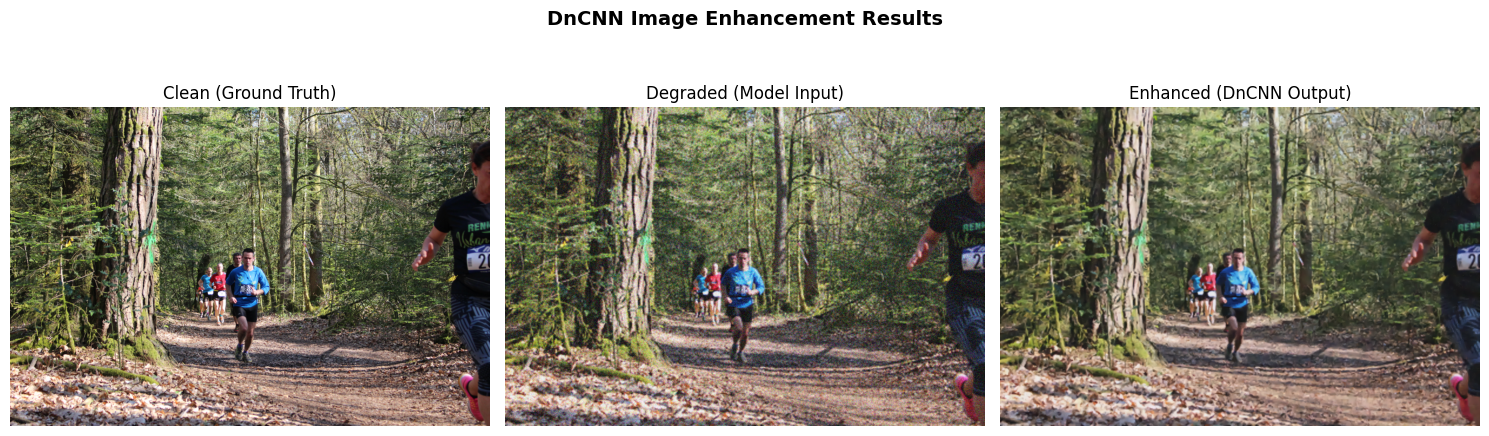

Figure saved to comparison_figure.png


In [ ]:
# Cell 14: Ryan Darghous - Visualization Section
# side-by-side comparison: clean vs degraded vs enhanced (DnCNN output)

import cv2
import matplotlib.pyplot as plt

name = "image_0.png"

clean    = cv2.cvtColor(cv2.imread(f"data/clean/{name}"),    cv2.COLOR_BGR2RGB)
degraded = cv2.cvtColor(cv2.imread(f"data/degraded/{name}"), cv2.COLOR_BGR2RGB)
enhanced = cv2.cvtColor(cv2.imread(f"data/enhanced/{name}"), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(clean)
plt.title("Clean (Ground Truth)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(degraded)
plt.title("Degraded (Model Input)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(enhanced)
plt.title("Enhanced (DnCNN Output)")
plt.axis("off")

plt.suptitle("DnCNN Image Enhancement Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_figure.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to comparison_figure.png")